In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
store = pd.read_csv('store.csv')

In [3]:
train = pd.read_csv('train.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_3516\2949129822.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train.csv')


In [4]:
train = pd.read_csv('train.csv', low_memory=False)

In [5]:
train.shape

(1017209, 9)

In [6]:
store.shape

(1115, 10)

In [7]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [8]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
train.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [10]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [11]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 98.0 KB


In [12]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 80.5 MB


In [13]:
train.duplicated().sum()

np.int64(0)

In [14]:
store.duplicated().sum()

np.int64(0)

In [15]:
print(store.groupby('Promo2')['Promo2SinceWeek'].apply(lambda x: x.isnull().sum()))

Promo2
0    544
1      0
Name: Promo2SinceWeek, dtype: int64


In [16]:
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0)

In [17]:
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0)

In [18]:
store['PromoInterval'] = store['PromoInterval'].fillna('None')

In [19]:
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)

In [20]:
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0)

In [21]:
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

In [22]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1115 non-null   float64
 4   CompetitionOpenSinceMonth  1115 non-null   float64
 5   CompetitionOpenSinceYear   1115 non-null   float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            1115 non-null   float64
 8   Promo2SinceYear            1115 non-null   float64
 9   PromoInterval              1115 non-null   str    
dtypes: float64(5), int64(2), str(3)
memory usage: 100.0 KB


In [23]:
df = train.merge(store, on='Store', how='left')

In [24]:
df.shape

(1017209, 18)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  float64
 13  CompetitionOpenSinceYea

In [26]:
df['Date'] = pd.to_datetime(df['Date'])

In [27]:
 df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1017209 non-null  flo

In [28]:
df['Sales'].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

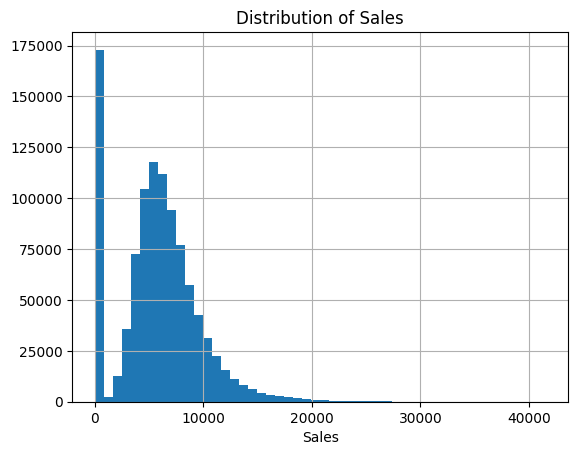

In [29]:
df['Sales'].hist(bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.show()

In [30]:
open_df = df[df['Open'] == 1]

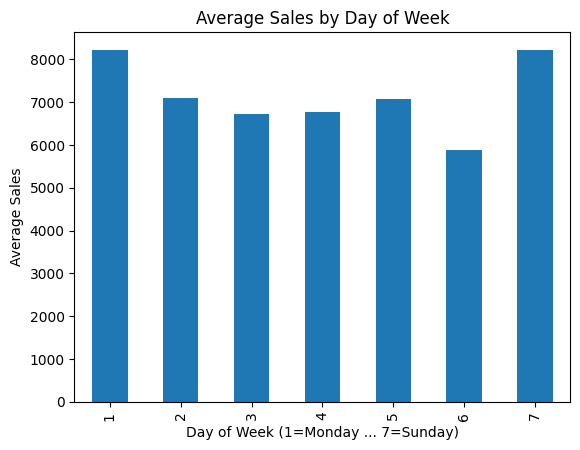

In [31]:
open_df.groupby('DayOfWeek')['Sales'].mean().plot(kind='bar')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week (1=Monday ... 7=Sunday)')
plt.ylabel('Average Sales')
plt.show()

In [32]:
open_df.groupby('Promo')['Sales'].mean()

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

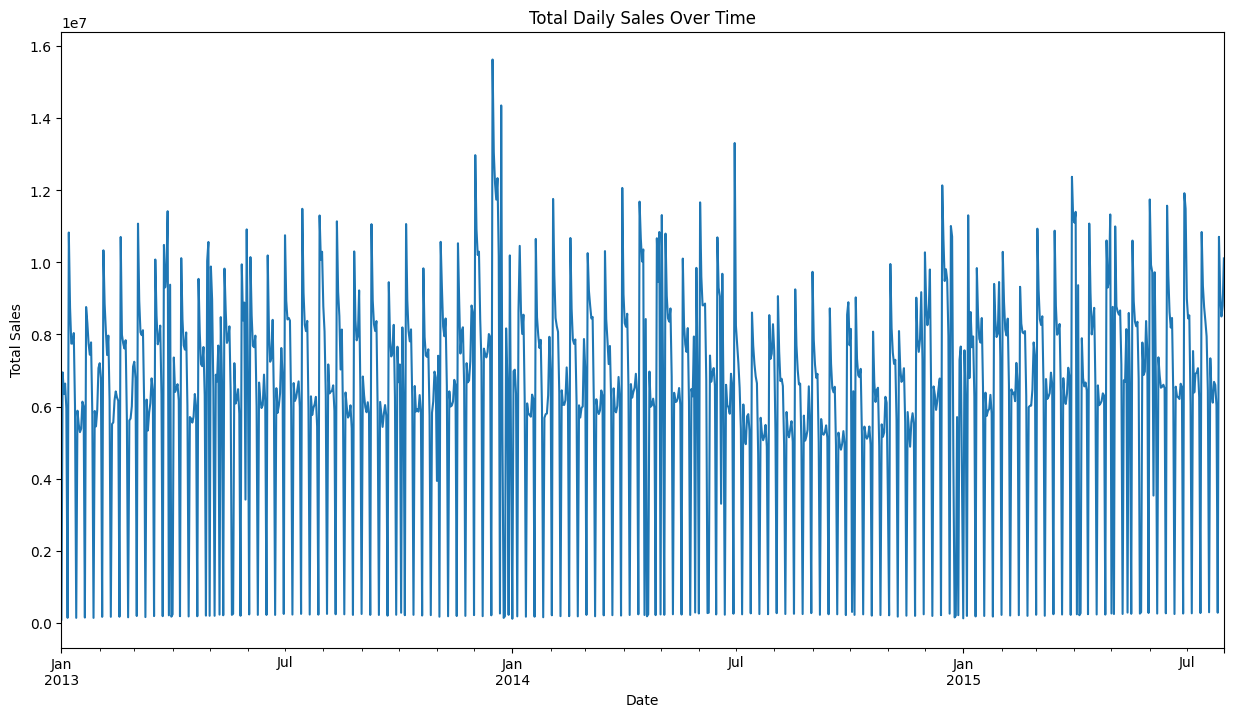

In [33]:
df.groupby('Date')['Sales'].sum().plot(figsize=(15,8))
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

In [34]:
open_df.groupby('StateHoliday')['Sales'].mean()

StateHoliday
0    6953.515034
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64

In [35]:
df['Year'] = df['Date'].dt.year

In [36]:
df['Month'] = df['Date'].dt.month

In [37]:
df['Day'] = df['Date'].dt.day

In [38]:
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [39]:
df[['Date', 'Year', 'Month', 'Day', 'WeekOfYear']].head()

,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [40]:
df['CompetitionOpen'] = 12 * (df['Year'] - df['CompetitionOpenSinceYear']) + \
                         (df['Month'] - df['CompetitionOpenSinceMonth'])

In [41]:
df['CompetitionOpen'] = df['CompetitionOpen'].clip(lower=0)

In [42]:
df[['Date', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'CompetitionOpen']].sample(20)

,Date,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionOpen
198726,2015-02-03,12.0,2012.0,26.0
286462,2014-11-08,4.0,2015.0,0.0
287967,2014-11-06,11.0,2002.0,144.0
103537,2015-04-30,11.0,2013.0,17.0
1552,2015-07-30,0.0,0.0,24187.0
233874,2015-01-03,9.0,2009.0,64.0
138512,2015-03-29,0.0,0.0,24183.0
492924,2014-04-16,0.0,0.0,24172.0
207989,2015-01-26,6.0,2010.0,55.0
689046,2013-10-22,0.0,0.0,24166.0


In [43]:
has_competition_data = df['CompetitionOpenSinceYear'] > 0

In [44]:
df['CompetitionOpen'] = 0

In [45]:
def calculate_competition_open(row):
    if row['CompetitionOpenSinceYear'] == 0:
        return 0
    
    months_open = 12 * (row['Year'] - row['CompetitionOpenSinceYear']) + (row['Month'] - row['CompetitionOpenSinceMonth'])
    
    if months_open < 0:
        return 0
    
    return months_open

In [46]:
df['CompetitionOpen'] = df.apply(calculate_competition_open, axis=1)

In [47]:
df[['Date', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'CompetitionOpen']].sample(15)

,Date,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionOpen
147639,2015-03-21,4.0,2008.0,83.0
442804,2014-05-31,6.0,2010.0,47.0
927545,2013-03-22,0.0,0.0,0.0
403686,2014-07-06,4.0,2005.0,111.0
181936,2015-02-18,3.0,2008.0,83.0
1006476,2013-01-10,0.0,0.0,0.0
362364,2014-08-19,3.0,2012.0,29.0
209363,2015-01-25,7.0,2015.0,0.0
671877,2013-11-06,3.0,2014.0,0.0
843174,2013-06-06,8.0,2015.0,0.0


In [48]:
def calculate_promo2_active(row):
    
    result = 0
    
    if row['Promo2'] == 1:
      
        weeks_active = 52 * (row['Year'] - row['Promo2SinceYear']) + (row['WeekOfYear'] - row['Promo2SinceWeek'])
        
        if weeks_active >= 0:
            result = 1
    return result

In [49]:
df['Promo2Active'] = df.apply(calculate_promo2_active, axis=1)

In [50]:
df[['Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'WeekOfYear', 'Year', 'Promo2Active']].sample(15)

,Promo2,Promo2SinceWeek,Promo2SinceYear,WeekOfYear,Year,Promo2Active
871362,1,9.0,2011.0,19,2013,1
736703,1,14.0,2011.0,37,2013,1
227306,0,0.0,0.0,2,2015,0
99692,0,0.0,0.0,18,2015,0
633052,1,13.0,2010.0,50,2013,1
162864,0,0.0,0.0,10,2015,0
172349,0,0.0,0.0,9,2015,0
47468,0,0.0,0.0,25,2015,0
394511,0,0.0,0.0,29,2014,0
105081,1,14.0,2011.0,18,2015,1


In [51]:
print(df['StoreType'].unique())
print(df['StoreType'].value_counts())

<ArrowStringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str
StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64


In [52]:
print(df['Assortment'].unique())
print(df['Assortment'].value_counts())

<ArrowStringArray>
['a', 'c', 'b']
Length: 3, dtype: str
Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64


In [53]:
print(df['StateHoliday'].unique())
print(df['StateHoliday'].value_counts())

<ArrowStringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [54]:
print(df['PromoInterval'].unique())
print(df['PromoInterval'].value_counts())

<ArrowStringArray>
['None', 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec']
Length: 4, dtype: str
PromoInterval
None                508031
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64


In [55]:
df.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[us]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                            str
SchoolHoliday                         int64
StoreType                               str
Assortment                              str
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                           str
Year                                  int32
Month                                 int32
Day                                   int32
WeekOfYear                           UInt32
CompetitionOpen                 

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 24 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1017209 non-null  flo

In [57]:
df = pd.get_dummies(df, columns=['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval'], drop_first=True)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 31 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   Store                           1017209 non-null  int64         
 1   DayOfWeek                       1017209 non-null  int64         
 2   Date                            1017209 non-null  datetime64[us]
 3   Sales                           1017209 non-null  int64         
 4   Customers                       1017209 non-null  int64         
 5   Open                            1017209 non-null  int64         
 6   Promo                           1017209 non-null  int64         
 7   SchoolHoliday                   1017209 non-null  int64         
 8   CompetitionDistance             1017209 non-null  float64       
 9   CompetitionOpenSinceMonth       1017209 non-null  float64       
 10  CompetitionOpenSinceYear        1017209 non-null  flo

In [59]:
df = df.drop(columns=['Customers'])

In [60]:
df = df.drop(columns=['Date'])

In [61]:
df = df[df['Open'] == 1]

In [62]:
df = df.drop(columns=['Open'])

In [63]:
print(df.shape)
print(df.columns.tolist())

(844392, 28)
['Store', 'DayOfWeek', 'Sales', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day', 'WeekOfYear', 'CompetitionOpen', 'Promo2Active', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_None']


In [64]:
df = df.sort_values(['Year', 'Month', 'Day'])

In [65]:
train_data = df[(df['Year'] < 2015) | ((df['Year'] == 2015) & (df['Month'] <= 5))]

In [66]:
test_data = df[(df['Year'] == 2015) & (df['Month'] > 5)]

In [67]:
print(train_data.shape)

(785781, 28)


In [68]:
print(test_data.shape)

(58611, 28)


In [69]:
X_train = train_data.drop(columns=['Sales'])

In [70]:
y_train = train_data['Sales']

In [71]:
X_test = test_data.drop(columns=['Sales'])

In [72]:
y_test = test_data['Sales']

In [73]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(785781, 27) (785781,)
(58611, 27) (58611,)


In [74]:
from sklearn.linear_model import LinearRegression

In [75]:
lr_model = LinearRegression()

In [76]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](27,)","[ 0.05,-139.86,2135.45,..., 240.82,-363.91, 0.41]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](27,)","['Store','DayOfWeek','Promo',...,'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec','PromoInterval_None']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.925e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,27
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,25


In [77]:
lr_preds = lr_model.predict(X_test)

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [79]:
mae = mean_absolute_error(y_test, lr_preds)

In [80]:
rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

In [81]:
r2 = r2_score(y_test, lr_preds)

In [82]:
print(mae)
print(rmse)
print(r2)

1977.5830766285635
2674.0088220079692
0.26127162793970893


In [83]:
from sklearn.ensemble import RandomForestRegressor

In [84]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

In [85]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [86]:
rf_preds = rf_model.predict(X_test)

In [87]:
rf_mae = mean_absolute_error(y_test, rf_preds)

In [88]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

In [89]:
rf_r2 = r2_score(y_test, rf_preds)

In [90]:
print(rf_mae)
print(rf_rmse)
print(rf_r2)

766.7770138711164
1107.8186122104041
0.8732066657965103


In [91]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

In [92]:
importances = importances.sort_values('importance', ascending=False)

In [93]:
print(importances)

                           feature  importance
4              CompetitionDistance    0.190211
0                            Store    0.147031
2                            Promo    0.132406
1                        DayOfWeek    0.067949
5        CompetitionOpenSinceMonth    0.064804
6         CompetitionOpenSinceYear    0.064724
14                 CompetitionOpen    0.047636
12                             Day    0.043771
13                      WeekOfYear    0.038913
9                  Promo2SinceYear    0.038452
8                  Promo2SinceWeek    0.027386
16                     StoreType_b    0.026849
20                    Assortment_c    0.023979
11                           Month    0.017073
17                     StoreType_c    0.014574
18                     StoreType_d    0.013221
10                            Year    0.009257
25  PromoInterval_Mar,Jun,Sept,Dec    0.007123
3                    SchoolHoliday    0.006796
24   PromoInterval_Jan,Apr,Jul,Oct    0.006197
15           

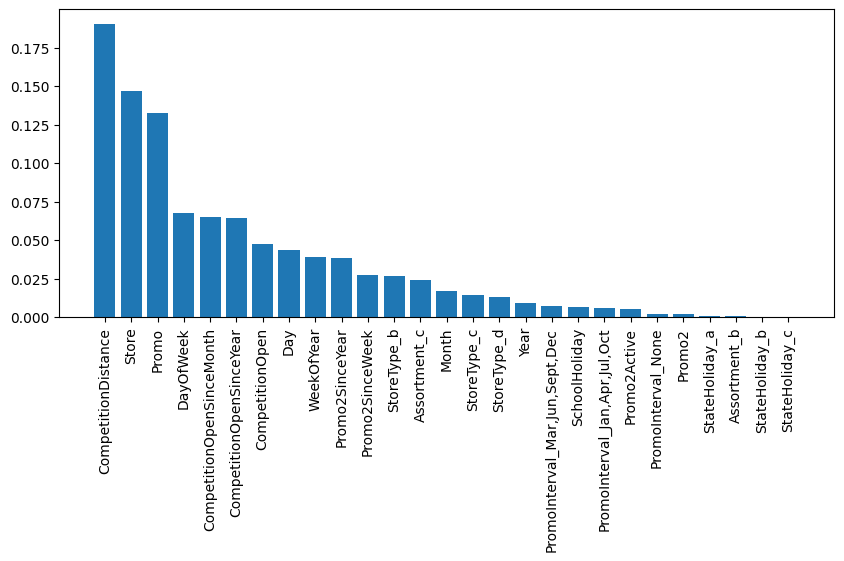

In [94]:
plt.figure(figsize=(10,4))
plt.bar(importances['feature'], importances['importance'])
plt.xticks(rotation=90)
plt.show()

In [95]:
import lightgbm as lgb

In [96]:
lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)

In [97]:
X_train = X_train.rename(columns={
    'PromoInterval_Jan,Apr,Jul,Oct': 'PromoInterval_JanAprJulOct',
    'PromoInterval_Mar,Jun,Sept,Dec': 'PromoInterval_MarJunSeptDec'
})

In [98]:
X_test = X_test.rename(columns={
    'PromoInterval_Jan,Apr,Jul,Oct': 'PromoInterval_JanAprJulOct',
    'PromoInterval_Mar,Jun,Sept,Dec': 'PromoInterval_MarJunSeptDec'
})

In [99]:
print(X_train.columns.tolist())

['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day', 'WeekOfYear', 'CompetitionOpen', 'Promo2Active', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'PromoInterval_JanAprJulOct', 'PromoInterval_MarJunSeptDec', 'PromoInterval_None']


In [100]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.107398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 975
[LightGBM] [Info] Number of data points in the train set: 785781, number of used features: 27
[LightGBM] [Info] Start training from score 6940.222064


,learning_rate,0.05
,n_estimators,200
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [101]:
lgb_preds = lgb_model.predict(X_test)

In [102]:
lgb_mae = mean_absolute_error(y_test, lgb_preds)

In [103]:
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))

In [104]:
lgb_r2 = r2_score(y_test, lgb_preds)

In [105]:
print(lgb_mae)
print(lgb_rmse)
print(lgb_r2)

1328.591131377679
1779.3769926369769
0.6728890748598094
